In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import cudaq

from utils import (
    generate_graph,
    process_max_cut,
    color_graph,
    draw_graph,
    mark_edges,
    brute_force
)

from qaoa import (
    qaoa_kernel,
    optimize_qaoa
)

from rqaoa import (
    compute_correlations,
    contract_graph,
    reconstruct_solution
)

In [2]:
n = 14
m = 7

layer_count = 1
seed = 42
shots = 5000
maxiter = 100

cudaq.set_target("nvidia", option='mgpu')
cudaq.set_random_seed(seed)

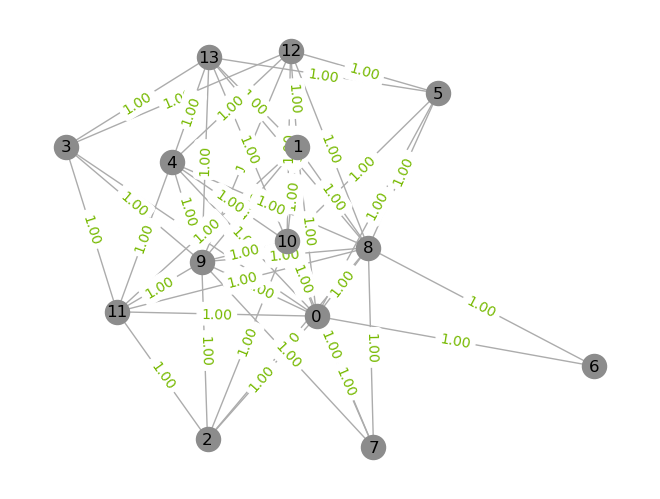

In [3]:
G = generate_graph(n, m)

edge_list = G.edges
nodes = list(G.nodes())
qubit_count = len(nodes)

qubit_source = list()
qubit_target = list()
n_edges = 0
for u, v in nx.edges(G):
    qubit_source.append(nodes.index(u))
    qubit_target.append(nodes.index(v))
    n_edges += 1

color_map = '#8c8c8c'
edge_color_map = '#acacac'
pos = nx.spring_layout(G, seed=seed)

edge_weights = nx.get_edge_attributes(G, 'weight')
nx.draw(
    G,
    with_labels=True,
    pos=pos,
    node_color=color_map,
    edge_color=edge_color_map,
)
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels={edge: f"{weight:.2f}" for edge, weight in edge_weights.items()},
    font_color='#76b900',
    font_size=10
)
plt.show()

In [4]:
ground_truth_max_cut_value, ground_truth_max_cut_edges, ground_truth_max_subset = brute_force(G)
print(f'Ground Truth\n{"="*12}\nvalue = {ground_truth_max_cut_value}')
for u, v in ground_truth_max_cut_edges:
    print(f'{u} {v}')

Ground Truth
value = 36
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 9
1 8
1 10
1 11
1 12
1 13
2 8
2 10
2 11
3 11
3 12
3 13
4 8
4 10
4 11
4 12
4 13
5 8
5 10
5 12
5 13
6 8
7 8
7 10
8 9
9 10
9 11
9 12
9 13


In [5]:
def solve_rqaoa(
    G: nx.Graph,
    layer_count: int,
    shots: int=1000,
    seed: int=42,
    method: str='COBYLA',
    cutoff: int=3,
    maxiter: int=100
):
    current_graph = G.copy()
    elimination_history = list() # [(u, v, cor, +-)]
    losses = list()

    step = 1

    while current_graph.number_of_nodes() > cutoff:
        params, node_map, loss = optimize_qaoa(current_graph, layer_count, shots, seed, method, maxiter)
        correlations = compute_correlations(current_graph, params, layer_count, node_map)
        losses.append((current_graph.number_of_nodes(), loss))

        max_edge = max(correlations, key=lambda e: abs(correlations[e]))
        max_corr = correlations[max_edge]
        u, v = max_edge

        correlation_sign = np.sign(max_corr)

        elimination_history.append((u, v, max_corr, correlation_sign))
        current_graph = contract_graph(current_graph, u, v, correlation_sign)
        step += 1

        edge_weights = nx.get_edge_attributes(current_graph, 'weight')
        nx.draw(
            current_graph,
            with_labels=True,
            pos=pos,
            node_color=color_map,
            edge_color=edge_color_map,
        )
        nx.draw_networkx_edge_labels(
            current_graph,
            pos,
            edge_labels={edge: f"{weight:.2f}" for edge, weight in edge_weights.items()},
            font_color='#EA4335',
            font_size=10
        )
        plt.show()

    _, _, max_subset = brute_force(current_graph)

    max_subset = max_subset or ()

    base_solution = {}
    for node in current_graph.nodes():
        base_solution[node] = 1 if node in max_subset else -1

    final_solution = reconstruct_solution(base_solution, elimination_history)

    return final_solution, current_graph, losses, elimination_history


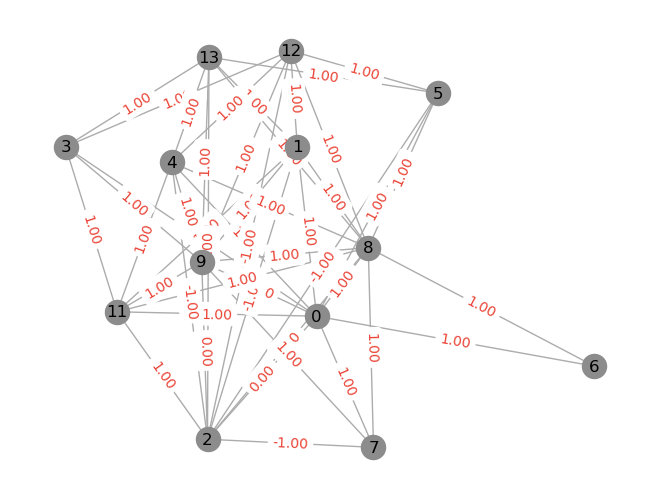

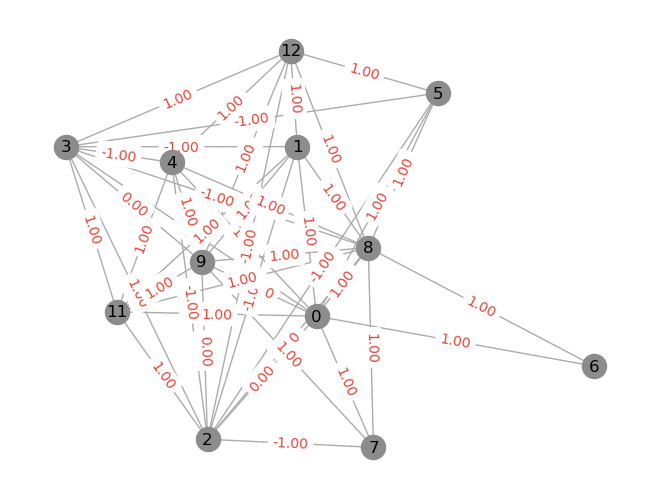

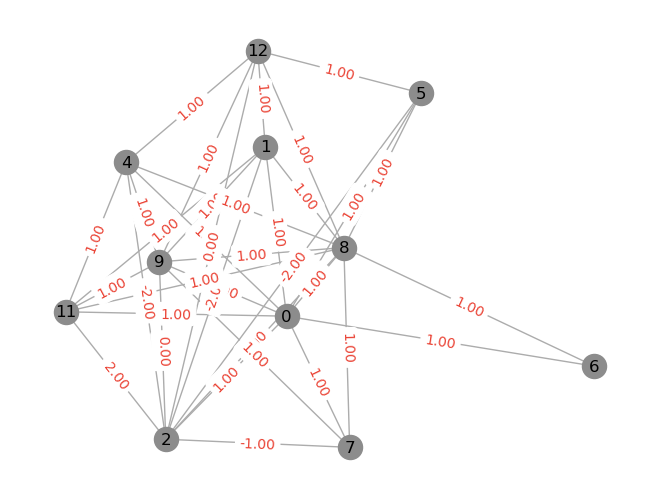

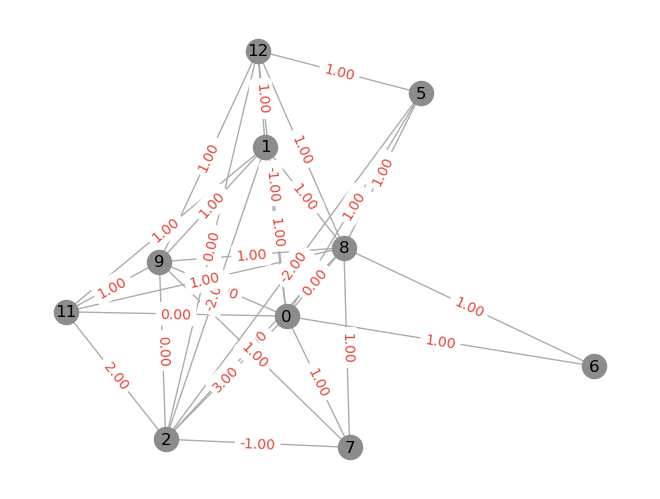

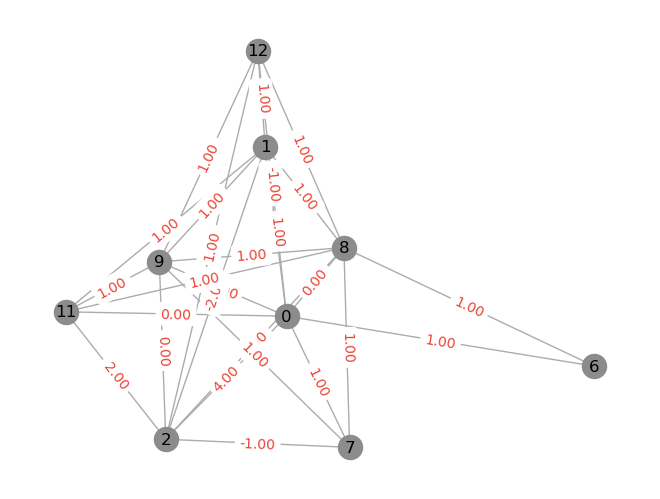

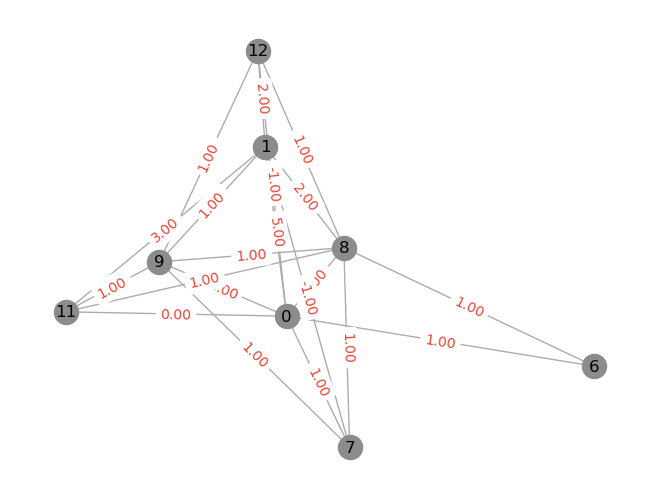

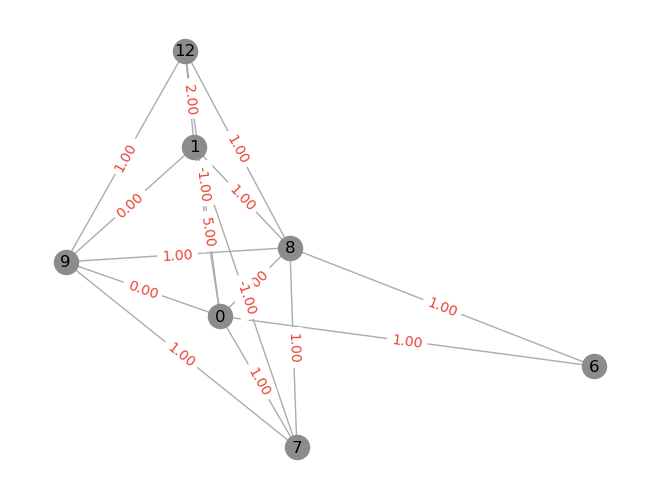

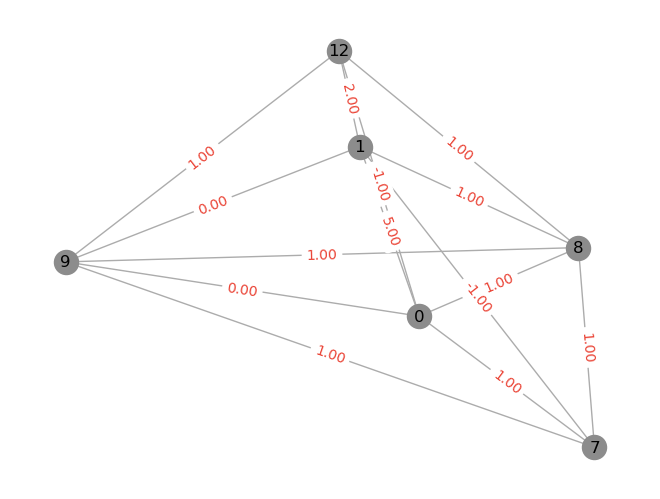

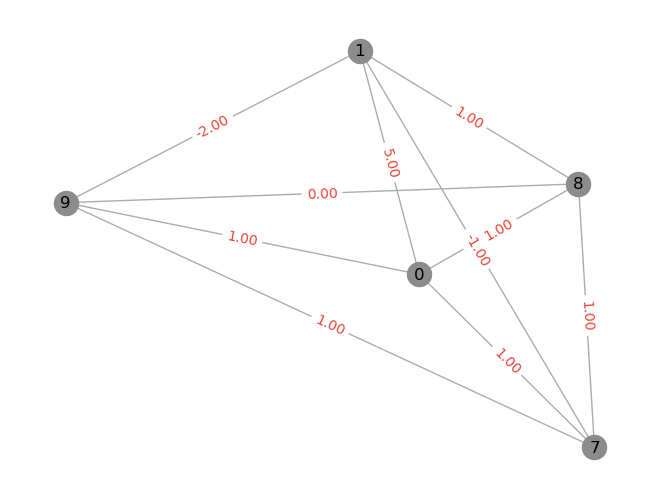

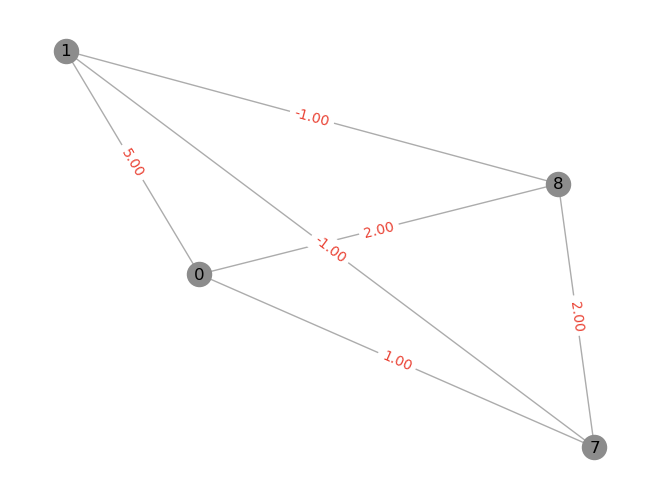

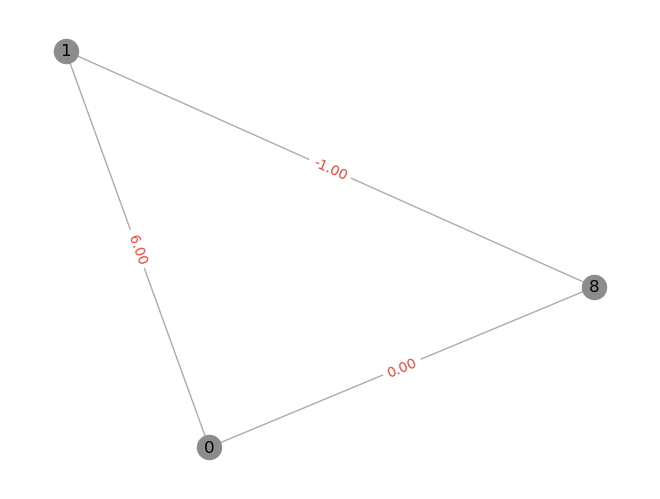

In [6]:
final_solution, G_current, losses, elimination_history = solve_rqaoa(G, layer_count, shots=shots, seed=seed, method='COBYLA', maxiter=maxiter)

In [7]:
subset = list()

for node, color in final_solution.items():
    if color == 1:
        nx.nodes(G)[node]['color'] = int(color)
        subset.append(node)
    else:
        nx.nodes(G)[node]['color'] = 0

subset = set(subset)

In [8]:
max_cut_value, max_cut_edges = process_max_cut(G)
print(f'RQAOA\n{"="*12}\nvalue = {max_cut_value}')
for u, v in max_cut_edges:
    print(f'{u} {v}')

RQAOA
value = 33
0 1
0 2
0 3
0 4
0 5
0 7
0 8
0 9
1 10
1 11
1 12
1 13
2 10
2 11
3 11
3 12
3 13
4 10
4 11
4 12
4 13
5 10
5 12
5 13
6 8
7 10
8 11
8 12
8 13
9 10
9 11
9 12
9 13


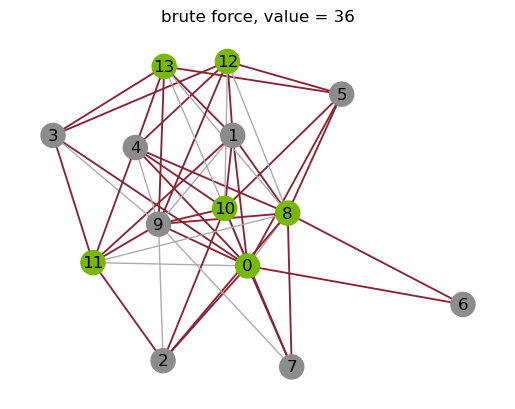

In [9]:
nx.set_node_attributes(G, values=0, name='color')
G_brute_force = color_graph(G, ground_truth_max_subset, 1)
G_brute_force = mark_edges(G_brute_force, ground_truth_max_cut_edges)
plt.title(f'brute force, value = {ground_truth_max_cut_value}')
draw_graph(G_brute_force)
plt.show()

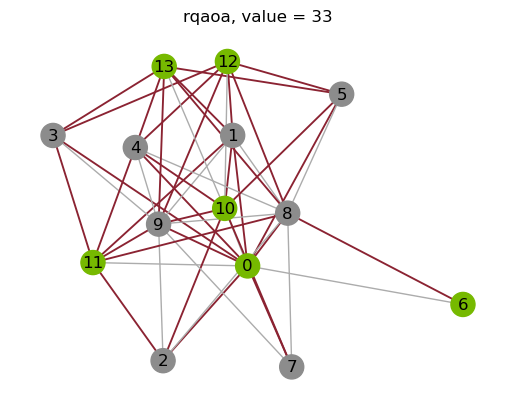

In [10]:
nx.set_node_attributes(G, values=0, name='color')
G_rqaoa = color_graph(G, subset, 1)
G_rqaoa = mark_edges(G_rqaoa, max_cut_edges)
plt.title(f'rqaoa, value = {max_cut_value}')
draw_graph(G_rqaoa)
plt.show()